Set up:

- install the `ivt` environment (see `inv-render-template/README.md`)

- `jupyter` is installed within the `ivt` conda environment.

- `matplotlib` is installed via `pip` for illustration purposes. (Note: using conda instead of pip will cause version conflict of dependencies)

In [ ]:

#     # Metropolis-Hasting algorithm
#     # T: allowed computation time budget
#     def sample(self, T):
#         # Question: normalizing parameters (mapping range to -inf~inf)?
#         para = th.tensor(self.forwardObj.para, dtype=th.float32, device=self.forwardObj.device)
#         x0 = self.forwardObj.orig_to_norm(para)
#         xs = [self.forwardObj.norm_to_orig(x0).cpu().numpy()]

#         lpdf, img = self.U(x0)
#         lpdfs = [lpdf.item()]

#         best_lpdf = lpdfs[-1]
#         best_id = 0
#         best_img = img
#         best_para = xs[-1]

#         initTime = time.time()
#         while (time.time() - initTime) < T:
#             self.N = self.num_accept + self.num_reject
            
#             # At checkpoint, print stats and save best image
#             if self.N%100==0:
#                 print('accept:%d, reject:%d, accept rate:%.2f%%' % \
#                     (self.num_accept, self.num_reject, self.num_accept*100/max(1,self.N)))
#                 print('Best parameters so far: ', best_para)

#                 xs_arr = np.vstack(xs)
#                 lpdfs_arr = np.vstack(lpdfs)
#                 id = np.vstack(np.arange(len(lpdfs)))
#                 np.savetxt(os.path.join(self.dir, 'sample.csv'),
#                     np.concatenate((id, lpdfs_arr, xs_arr), 1),
#                     delimiter=",", fmt='%.3f')
#                 gyArray2PIL(gyTensor2Array(best_img)).save(os.path.join(self.dir, 'bestfit_%d_%.3f.png' % (best_id, best_lpdf)))
#                 best_lpdf = 99999

#             # generate proposal sample
#             arej, x_tmp, lpdf, img = self.mcmc(x0)

#             # decide whether to accept or reject proposal
#             if np.random.rand() < min(1, arej):
#                 self.num_accept += 1
#                 x0 = x_tmp
#                 xs.append(self.forwardObj.norm_to_orig(x0).cpu().numpy())
#                 lpdfs.append(lpdf.item())
#                 if lpdfs[-1] < best_lpdf:
#                     best_lpdf = lpdfs[-1]
#                     best_id = len(lpdfs)-1
#                     best_img = img
#                     best_para = xs[-1]
#             else:
#                 self.num_reject += 1

# #         print('accept:%d, reject:%d, accept rate:%.2f%%' % \
# #             (self.num_accept, self.num_reject, self.num_accept*100/max(1,self.N)))
# #         print('Best parameters so far: ', best_para)

# #         plotFigure(self.dir,
# #             np.vstack(lpdfs),
# #             xs,
# #             img.detach().cpu().numpy(),
# #             self.sumfuncObj.target.cpu().numpy(),
# #             len(xs),
# #             self.num_reject,
# #             time.time()-initTime)

#         return xs, lpdfs

## MALA Test

In this test, we render a quad surface with a textured diffuse BRDF lit by a small area light. The target image is a synthetic render of the scene using a wooden texture. Per-pixel L2 loss is computed and used in a normal distribution to obtain a pdf (see mean_var logpdf). We use MALA algorithm to sample the posterior distribution of the parameter (texture).


### Renderer & target image setup

We use `ivt` (a wrapper of `psdr-jit`) as our renderer, set up a scene, and use a wooden texture to obtain a single target image.

In [1]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image

In [2]:
import torch

In [1]:
scene = Scene()
diffuse = read_image('assets/polyhaven/textures/raw_plank_wall_diff_1k.exr')
black = (0,0,0)
scene.set('mat', DiffuseBRDF(diffuse))
scene.set('black', DiffuseBRDF(black))
scene.set('mesh1', Mesh.from_file("quad.obj", 'mat')) # surface to reconstruct
scene.set('mesh2', Mesh.from_file("light.obj", 'black', radiance=400)) # area light source
# scene.set('envmap', EnvironmentLight.from_file('assets/polyhaven/envmaps/rural_asphalt_road_2k.exr'))
scene.set('film', HDRFilm(1280, 720))
scene.set('integrator', Integrator('path', {'max_depth': 3, 'hide_emitters': True}))
scene.set('cam1', PerspectiveCamera.from_lookat(fov=45, origin=(3,3,0), target=(0,0,0), up=(0,1,0))) # camera

NameError: name 'Scene' is not defined

In [4]:
renderer_hi = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 128,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})

# Use lower spp for sampling process
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 4,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})

In [5]:
# Render our target Image
I_t = renderer_hi(scene)

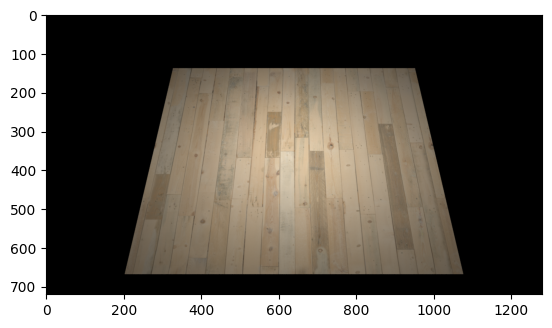

In [6]:
# Visualize the target Image
from matplotlib import pyplot as plt
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
def showhist(a):
    plt.hist(a.view(-1).detach().cpu().numpy(), bins=100)
showimg(I_t)

### Loss Function (Posterior Distribution)

Because we're reconstructing the texture for an exact match, we can simply use per-pixel loss in the image space.

In [7]:
def logpdf(img):
    from math import sqrt, pi
    sigma = torch.tensor(0.02)
    # log of density of a normal distribution
    lpdf = ((img - I_t).pow(2.0)/(2.0*sigma.pow(2.0)) + \
                (sqrt(2*pi)*sigma).log()).mean()
    return lpdf

### MALA algorithm

Under the Bayesian formulation of the material estimation problem, we use MALA to sample the posterior distribution of the material parameters defined by `logpdf`. For now no prior is applied.

Credit https://github.com/tflsguoyu/proceduralmat

TODO: tune hyper-parameters

In [8]:
from torch.distributions import Normal

eps = 1e-8

In [9]:
def orig_to_norm(x):
    return torch.log(x/(1-x))

def norm_to_orig(y):
    return torch.sigmoid(y)

In [10]:
# potential energy in the parametric space
def U(x):
    scene['mat']['d'] = norm_to_orig(x)
    scene.configure()
    img = renderer(scene)
    lpdf = logpdf(img)
    return lpdf, img

# gradient of the potential energy
def dU(x):
    x.requires_grad = True
    if x.grad is not None:
        x.grad.zero_()
    lpdf, img = U(x)
    lpdf.backward()
    return x.grad

In [11]:
num_pixel = scene['mat']['d'].shape[:-1]
num_accept = torch.zeros(num_pixel).to(int).to(device=0)
num_reject = torch.zeros(num_pixel).to(int).to(device=0)

In [12]:
class MALA:
    def __init__(self):
        print("Initial Class MALA()")
#         super().__init__()
        # Hyper-parameters for the MALA algorithm
        self.alpha = 0.9
        self.beta = 0.999
        self.c1 = 0.25
        self.c2 = 0.25
        self.delta = 0.01 # learning rate
        # momentum for each independent set (pixel) of parameters
        self.V1 = 0
        self.V2 = 0

    def proposal(self, x0):
        # Compute initial potential energy and its gradient
        U_this, _ = U(x0)
        dU_this   = dU(x0)
        
        with torch.no_grad():
            # compute first and second momentum
            V1_this = self.alpha * self.V1 + (1 - self.alpha) * dU_this
            V2_this = self.beta  * self.V2 + (1 - self.beta)  * dU_this * dU_this

            # calculate mean and variance of the proposal distribution
            num_accept_ = num_accept.unsqueeze(-1).expand(-1, -1, x0.shape[-1]).float().clamp(min=eps)
            M1 = num_accept_**-self.c1 * V1_this + dU_this
            M2 = 1/(eps + num_accept_**-self.c2 * V2_this.clamp(min=eps).sqrt())

            # generate proposal sample of that distribution
            mu = x0 - 0.5 * self.delta * M1 * M2
            sigma2 = self.delta * M2
            sigma = sigma2.clamp(min=eps).sqrt()
            distr = Normal(mu, sigma)
            x_tmp = distr.sample()
            q_this = torch.exp(distr.log_prob(x_tmp).sum(dim=-1)) # pdf of sample
        
        # compute potential energy and gradient for the proposal
        U_tmp, img = U(x_tmp)
        dU_tmp     = dU(x_tmp)

        with torch.no_grad():
            # compute first and second momentum for the proposal
            V1_tmp = self.alpha * self.V1 + (1 - self.alpha) * dU_tmp
            V2_tmp = self.beta  * self.V2 + (1 - self.beta)  * dU_tmp * dU_tmp

            # calculate mean and variance for the reverse transition
            M1 = num_accept_**-self.c1 * V1_tmp + dU_tmp
            M2 = 1/(eps + num_accept_**-self.c2 * V2_tmp.clamp(min=eps).sqrt())

            # calculate reverse transition probability
            mu = x_tmp - 0.5 * self.delta * M1 * M2
            sigma2 = self.delta * M2
            sigma = sigma2.clamp(min=eps).sqrt()
            distr = Normal(mu, sigma)
            q_tmp = torch.exp(distr.log_prob(x0).sum(dim=-1)) # pdf of reverse sample

            # calculate acceptance ratio
            arej = torch.exp((U_this-U_tmp).clamp(max=88)) * q_tmp / (q_this + eps)

            # update first and second momentum
            self.V1 = V1_this
            self.V2 = V2_this

        return arej, x_tmp, U_tmp, img

In [13]:
mcmc = MALA()

Initial Class MALA()


In [14]:
x0 = orig_to_norm(torch.empty_like(scene['mat']['d']).uniform_(0, 1))
x0.requires_grad = True
# scene.configure()
lpdf, img = U(x0)

In [15]:
for i in range(100):
    print("i:", i)
    # generate proposal sample
    arej, x_tmp, lpdf, img = mcmc.proposal(x0)
    # accept or reject proposal on a per-pixel basis
    accepts = torch.bernoulli(arej.clamp_max(1)).bool()
    num_accept += accepts
    print(accepts.shape, x_tmp.shape, x0.shape)
    x0 = torch.where(accepts.unsqueeze(-1), x_tmp, x0).detach()

i: 0
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 1
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 2
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 3
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 4
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 5
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 6
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 7
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 8
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 9
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 10
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 11
torch.Size([1024, 1024]) torch.Size([1024, 1024

torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 96
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 97
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 98
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])
i: 99
torch.Size([1024, 1024]) torch.Size([1024, 1024, 3]) torch.Size([1024, 1024, 3])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


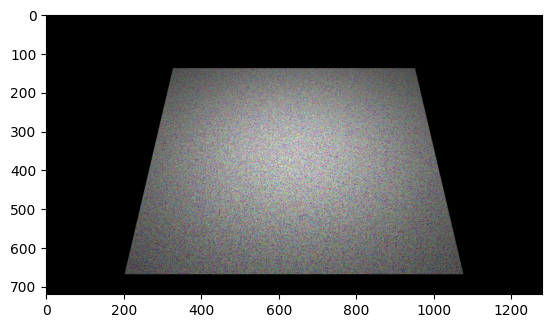

In [16]:
showimg(img)

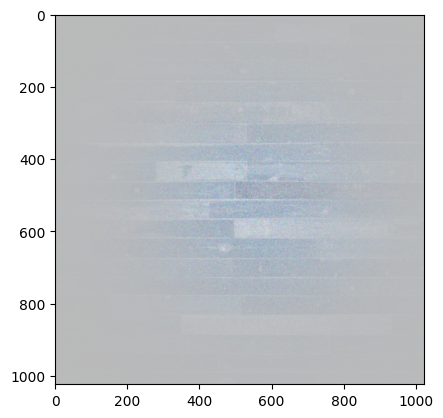

In [22]:
showimg(dU(x0)*1e4+0.5)

### Note

- Because loss is averaged over all pixels, the gradient for each pixel is very small
- Profile render & sample time